# L6.3 — RAG: Ingestion & Indexing

Hands-on notebook for the lesson [`6-3-rag-indexing.mdx`](../../llm-quest-theory/level-6/6-3-rag-indexing.mdx).

> **Learning objectives**
> - Build a small "Acme Corp handbook" corpus in Markdown and chunk it four different ways.
> - Compare fixed-size, overlapping, sentence-boundary, and structure-aware chunking on the same text.
> - Embed each chunk with `sentence-transformers/all-MiniLM-L6-v2`, attach metadata, and save to a simple on-disk index (JSON + NumPy).
> - Confirm an index smoke-test: cosine top-1 for a known query lands on the correct chunk.

## Connection to the theory
Covers **§1–§10** of the source `.mdx`. The next notebook (6-4) will retrieve from this index.

In [1]:
# ---- Setup ----
import os, re, json, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
from sentence_transformers import SentenceTransformer

SEED = 42
np.random.seed(SEED)
INDEX_DIR = pathlib.Path(os.environ.get("LLM_QUEST_DATA", "/tmp/data")) / "rag_index"
INDEX_DIR.mkdir(parents=True, exist_ok=True)
print("index dir:", INDEX_DIR)

index dir: /tmp/data/rag_index


## 1. A toy corpus — Acme Corp handbook in Markdown
Four short documents with a realistic structure (headings, paragraphs, lists).

In [2]:
DOCS = {
    "handbook.md": """# Employee Handbook

## Vacation
Full-time employees get 12 vacation days per year. After three years of service, this increases to 15 days. Requests must be submitted at least two weeks in advance through the HR portal.

## Sick Leave
Employees receive 10 paid sick days per year. A doctor's note is required for absences longer than three consecutive days.

## Working Hours
Standard hours are 9am to 6pm, Monday to Friday. Flexible start times between 8am and 10am are allowed with a manager's approval.
""",
    "remote-policy.md": """# Remote Work Policy

## Eligibility
Employees who have completed their probation period may request remote work.

## Schedule
Employees can work remotely up to two days per week with their manager's approval. Fully remote arrangements require VP-level sign-off.

## Equipment
The company provides a laptop and monitor stipend for remote workers. Internet reimbursement is up to fifty dollars per month.
""",
    "security.md": """# Security Guidelines

## Passwords
Passwords must be at least 12 characters long and include at least one number and one symbol. Rotate them every 90 days.

## Two-Factor Authentication
Two-factor authentication is mandatory for all corporate accounts.

## Incident Reporting
Report any suspected security incident immediately to security@acme.example by email or through the hotline.
""",
    "expenses.md": """# Expense Policy

## Travel
Domestic travel under 500 USD is pre-approved. International travel requires manager approval in advance.

## Meals
Daily meal allowance is 50 USD domestic, 80 USD international. Receipts are required for all expenses over 25 USD.

## Reimbursement
Submit receipts through the expense portal within 30 days of travel. Late submissions may be denied.
""",
}

# Persist for the next notebook to reuse.
CORPUS_DIR = pathlib.Path(os.environ.get("LLM_QUEST_DATA", "/tmp/data")) / "rag_corpus"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
for name, content in DOCS.items():
    (CORPUS_DIR / name).write_text(content)
print("corpus written to:", CORPUS_DIR)
for p in sorted(CORPUS_DIR.glob("*.md")):
    print(f"  {p.name}  ({len(p.read_text())} chars)")

corpus written to: /tmp/data/rag_corpus
  expenses.md  (378 chars)
  handbook.md  (507 chars)
  remote-policy.md  (404 chars)
  security.md  (386 chars)


## 2. Four chunking strategies
All take a document string and return a list of `(text, metadata)` pairs.

In [3]:
def fixed_chunks(text, size=200, stride=None):
    """Strategy 1 or 2: fixed window of characters. Overlap when stride < size."""
    stride = stride or size
    out, start = [], 0
    while start < len(text):
        end = min(start + size, len(text))
        out.append(text[start:end])
        if end == len(text): break
        start += stride
    return out

def sentence_chunks(text, target=200):
    """Strategy 3 (poor-man's semantic chunking): group sentences up to ~target chars each."""
    sents = re.split(r"(?<=[.!?])\s+", text.strip())
    out, cur = [], ""
    for s in sents:
        if cur and len(cur) + len(s) + 1 > target:
            out.append(cur.strip()); cur = s
        else:
            cur = (cur + " " + s).strip()
    if cur: out.append(cur)
    return out

def structure_chunks(markdown_text):
    """Strategy 4: split by Markdown heading; each chunk keeps its heading as metadata."""
    chunks = []
    current_heading = "(preamble)"
    buffer = []
    for line in markdown_text.splitlines():
        if line.startswith("#"):
            if buffer:
                text = "\n".join(buffer).strip()
                if text: chunks.append((text, current_heading))
            current_heading = line.lstrip("# ").strip()
            buffer = []
        else:
            buffer.append(line)
    if buffer:
        text = "\n".join(buffer).strip()
        if text: chunks.append((text, current_heading))
    return chunks

# Compare on one document
sample = DOCS["handbook.md"]
print("fixed 200  : ", [len(c) for c in fixed_chunks(sample, 200)])
print("overlap 200/150:", [len(c) for c in fixed_chunks(sample, 200, stride=150)])
print("sentence 200:", [len(c) for c in sentence_chunks(sample, 200)])
print("structure  :", [(h, len(t)) for t, h in structure_chunks(sample)])

fixed 200  :  [200, 200, 107]
overlap 200/150: [200, 200, 200, 57]
sentence 200: [140, 139, 142, 80]
structure  : [('Vacation', 187), ('Sick Leave', 122), ('Working Hours', 129)]


Observations:
- **Fixed** chunks can cut mid-sentence.
- **Overlap** trades some redundancy for boundary protection.
- **Sentence** chunks respect punctuation but ignore structure.
- **Structure** chunks are the best fit for Markdown with clean headings.

For the rest of this notebook we use **structure-aware** chunking since our corpus is Markdown.

## 3. Build a full chunked corpus with metadata

In [4]:
def chunk_corpus():
    rows = []
    for name, content in DOCS.items():
        for i, (text, heading) in enumerate(structure_chunks(content)):
            rows.append({
                "chunk_id": f"{name}-{i}",
                "source":   name,
                "section":  heading,
                "n_chars":  len(text),
                "text":     text,
            })
    return rows

CHUNKS = chunk_corpus()
print(f"total chunks: {len(CHUNKS)}")
print("\nfirst 3 chunks:")
for row in CHUNKS[:3]:
    print(f"  {row['chunk_id']:<26}  [{row['section']}]  ({row['n_chars']} chars)")
    print("   ", row['text'][:100], "...\n")

total chunks: 12

first 3 chunks:
  handbook.md-0               [Vacation]  (187 chars)
    Full-time employees get 12 vacation days per year. After three years of service, this increases to 1 ...

  handbook.md-1               [Sick Leave]  (122 chars)
    Employees receive 10 paid sick days per year. A doctor's note is required for absences longer than t ...

  handbook.md-2               [Working Hours]  (129 chars)
    Standard hours are 9am to 6pm, Monday to Friday. Flexible start times between 8am and 10am are allow ...



## 4. Embed each chunk
`all-MiniLM-L6-v2` gives 384-D vectors. Normalise on output so cosine sim = dot product.

In [5]:
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
texts   = [c["text"] for c in CHUNKS]
embs    = encoder.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
print("embedding matrix:", embs.shape, "dtype:", embs.dtype)

embedding matrix: (12, 384) dtype: float32


## 5. Persist to disk — a minimal but real on-disk index
A professional pipeline would use FAISS / Qdrant / pgvector. For ~20 chunks, NumPy + JSON is perfectly adequate and keeps the data transparent.

In [6]:
np.save(INDEX_DIR / "embeddings.npy", embs)
with open(INDEX_DIR / "chunks.jsonl", "w") as f:
    for c in CHUNKS:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
print("wrote", INDEX_DIR / "embeddings.npy", "(", (INDEX_DIR / "embeddings.npy").stat().st_size, "bytes)")
print("wrote", INDEX_DIR / "chunks.jsonl",   "(", (INDEX_DIR / "chunks.jsonl").stat().st_size,   "bytes)")

wrote /tmp/data/rag_index/embeddings.npy ( 18560 bytes)
wrote /tmp/data/rag_index/chunks.jsonl ( 2727 bytes)


## 6. Smoke test — does the index return the right chunk?
Five probe queries, each with a hand-picked expected chunk id.

In [7]:
def search(query, k=3):
    q = encoder.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = embs @ q                              # normalised cosine
    idx  = np.argsort(-sims)[:k]
    return [(CHUNKS[i]["chunk_id"], CHUNKS[i]["section"], float(sims[i])) for i in idx]

PROBES = [
    ("How many vacation days do I get?",        "handbook.md-0"),
    ("Can I work remotely every day?",          "remote-policy.md-1"),
    ("What are the password rules?",            "security.md-0"),
    ("Do I need receipts for small purchases?", "expenses.md-1"),
    ("When do I need a doctor's note?",         "handbook.md-1"),
]

top1_hits = 0
print(f"{'query':<45} {'top1 id':<26} score  ✓?")
print("-" * 90)
for q, expected in PROBES:
    hits = search(q, k=1)
    got_id, got_section, got_score = hits[0]
    ok = got_id == expected
    top1_hits += int(ok)
    mark = "✓" if ok else "✗"
    print(f"{q[:43]:<45} {got_id:<26} {got_score:.3f}  {mark}")
print(f"\ntop-1 accuracy: {top1_hits}/{len(PROBES)}")

query                                         top1 id                    score  ✓?
------------------------------------------------------------------------------------------
How many vacation days do I get?              handbook.md-0              0.714  ✓
Can I work remotely every day?                remote-policy.md-1         0.652  ✓
What are the password rules?                  security.md-0              0.605  ✓
Do I need receipts for small purchases?       expenses.md-2              0.549  ✗
When do I need a doctor's note?               handbook.md-1              0.461  ✓

top-1 accuracy: 4/5


## 7. What do the chunks look like in vector space?
Quick sanity plot: 2-D projection, colour by source document. You should see each doc cluster together — semantically related sections (e.g. all of `handbook.md`) land nearby.

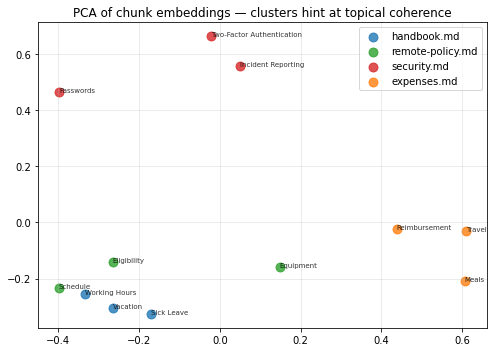

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=SEED).fit_transform(embs)
colors = {
    "handbook.md":     "tab:blue",
    "remote-policy.md":"tab:green",
    "security.md":     "tab:red",
    "expenses.md":     "tab:orange",
}
fig, ax = plt.subplots(figsize=(7, 5))
seen = set()
for c, (x, y) in zip(CHUNKS, coords):
    lbl = c["source"] if c["source"] not in seen else None
    seen.add(c["source"])
    ax.scatter(x, y, color=colors[c["source"]], s=80, alpha=0.8, label=lbl)
    ax.annotate(c["section"], (x, y), fontsize=7, alpha=0.8)
ax.set_title("PCA of chunk embeddings — clusters hint at topical coherence")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Quick checks

In [9]:
# Chunking must produce a non-trivial number of pieces
assert len(CHUNKS) >= 8, f"expected at least 8 chunks, got {len(CHUNKS)}"
# Every chunk has non-empty text and a section
assert all(c["text"] and c["section"] for c in CHUNKS)
# Embeddings are unit-normalised
assert np.allclose(np.linalg.norm(embs, axis=1), 1.0, atol=1e-5)
# Round-trip the saved index
loaded = np.load(INDEX_DIR / "embeddings.npy")
assert loaded.shape == embs.shape
assert np.allclose(loaded, embs)
# Smoke test passes top-1 on at least 4/5 probes
assert top1_hits >= 4, f"retrieval too weak: {top1_hits}/{len(PROBES)}"
print("OK — chunks, embeddings, persistence and smoke test all healthy.")

OK — chunks, embeddings, persistence and smoke test all healthy.


## Reflection questions

1. For a 200-page PDF (~400 k characters), what chunk size and overlap would you pick, and why?
2. Structure-aware chunking is great for clean Markdown. How would you handle a PDF with messy OCR where headings are not reliably detected?
3. The index here is brute-force `embs @ q`. At what corpus size would you need to move to HNSW or IVF (FAISS, Qdrant)?
4. Metadata is optional but often the cheapest win in RAG. Name three metadata fields you would add before going to production, and how each would be used.

## References
- Source theory: [`6-3-rag-indexing.mdx`](../../llm-quest-theory/level-6/6-3-rag-indexing.mdx)
- Next: [`6-4-rag-retrieval`](6-4-rag-retrieval.ipynb)